In [163]:
import numpy as np
from scipy.stats import f_oneway, ttest_ind
import pandas as pd
from itertools import combinations
import scikit_posthocs as sp
import matplotlib.pyplot as plt

In [164]:
df = pd.read_csv("pvalue_with_assemble.csv")

# models = sorted(df['model'].unique())
models = ['DL-CE', 'DL-DF', 'DL-WCD', 'DL-T', 'TFFM-CE', 'UN-DF', 'UN-WCD', 'ASSEMBLE']
dfs = {model: df[df['model'] == model] for model in models}

metrics = ['dice', 'iou', 'precision', 'recall']

# df_baseline = df[df['model']=="baseline"]
# df_dice_ce = df[df['model']=="dice_ce"]
# df_unetpp = df[df['model']=="unetpp"]

In [165]:
#baseline_IoU = [0.3630,0.3478,0.5970,0.4119,0.7219,0.5587,0.5674,0.6233,0.7910,0.2079,0.5643,0.4376,0.5091,0.0280]
#dice_ce_IoU = [0.3703, 0.6520,0.4005,0.7751,0.4437,0.5437,0.6157,0.7429,0.0000,0.5912,0.3950,0.5642,0.0000,0.4513]
#unetpp_IoU = [0.3620,0.6283,0.3997,0.7565,0.5450,0.5476,0.5954,0.7859,0.1266,0.6145,0.4574,0.5041,0.1814,0.4906]

# baseline_IoU = df_baseline['iou']
# dice_ce_IoU = df_dice_ce['iou']
# unetpp_IoU = df_unetpp['iou']
ious = {model: df['iou'] for model, df in dfs.items()}

# data = {'baseline':baseline_IoU, 'dice_ce':dice_ce_IoU, 'unetpp':unetpp_IoU}
# df = pd.DataFrame(data)

# f_stat, p_value = f_oneway(baseline_IoU,dice_ce_IoU, unetpp_IoU)
f_stat, p_value = f_oneway(*[ious[model] for model in models])

print(f"p-value: {p_value:.6f}")
print(f"Вывод: {'Модели различаются' if p_value < 0.05 else 'Разница не значима'}")

print("Между моделями:")
for list1, list2 in combinations(ious.keys(), 2):
    t, p = ttest_ind(ious[list1], ious[list2])
    print (list1, list2, p)

p-value: 0.000000
Вывод: Модели различаются
Между моделями:
DL-CE DL-DF 0.00015478097460732383
DL-CE DL-WCD 0.033964432375273135
DL-CE DL-T 0.13630304243845914
DL-CE TFFM-CE 2.6884073884944094e-05
DL-CE UN-DF 9.84775156219067e-05
DL-CE UN-WCD 1.1451485227147627e-06
DL-CE ASSEMBLE 1.4322063904442879e-05
DL-DF DL-WCD 0.182077178481497
DL-DF DL-T 0.22647567846217648
DL-DF TFFM-CE 0.00014637286979620284
DL-DF UN-DF 0.000517384244226615
DL-DF UN-WCD 2.2846458188625384e-06
DL-DF ASSEMBLE 2.9341347058524032e-05
DL-WCD DL-T 0.799804242790343
DL-WCD TFFM-CE 0.0009161132543962124
DL-WCD UN-DF 0.001268236347775799
DL-WCD UN-WCD 3.825694433599603e-05
DL-WCD ASSEMBLE 6.936963357339657e-05
DL-T TFFM-CE 0.0026137604744372075
DL-T UN-DF 0.0028860140168222837
DL-T UN-WCD 0.00013701774463489112
DL-T ASSEMBLE 0.00015160590839225947
TFFM-CE UN-DF 0.6223498781624128
TFFM-CE UN-WCD 8.07599793539099e-05
TFFM-CE ASSEMBLE 0.00024239454774509873
UN-DF UN-WCD 0.00031588497570093487
UN-DF ASSEMBLE 0.0004493848675

In [166]:
# baseline_dice = [ 0.5325, 0.5138, 0.7475, 0.5829, 0.8383, 0.7163, 0.7236, 0.7677, 0.8829, 0.3442, 0.7214, 0.6035, 0.6741, 0.0536]
# dice_ce_dice = [0.5380, 0.7891, 0.5698, 0.8730, 0.6142, 0.7041, 0.7621, 0.8522, 0.0000, 0.7428, 0.5610, 0.7210, 0.0000, 0.5780]
# unetpp_dice = [0.5292, 0.7717, 0.5702, 0.8610, 0.7043, 0.7073, 0.7455, 0.8800, 0.2245, 0.7609, 0.6234, 0.6695, 0.2822, 0.6331]

# baseline_dice = df_baseline['dice']
# dice_ce_dice = df_dice_ce['dice']
# unetpp_dice = df_unetpp['dice']
dices = {model: df['dice'] for model, df in dfs.items()}

# data_dice = {'baseline':baseline_dice, 'dice_ce':dice_ce_dice, 'unetpp':unetpp_dice}

f_stat_dice, p_value_dice = f_oneway(*[dices[model] for model in models])

print(f"p-value: {p_value_dice:.6f}")
print(f"Вывод: {'Модели различаются' if p_value_dice < 0.05 else 'Разница не значима'}")

print("Между моделями:")
for list1, list2 in combinations(dices.keys(), 2):
    t, p = ttest_ind(dices[list1], dices[list2])
    print (list1, list2, p)

p-value: 0.000000
Вывод: Модели различаются
Между моделями:
DL-CE DL-DF 0.0001823329033411529
DL-CE DL-WCD 0.0041319062404917084
DL-CE DL-T 0.023708499549894575
DL-CE TFFM-CE 2.150941933303463e-05
DL-CE UN-DF 7.481267131254422e-05
DL-CE UN-WCD 6.084158889073241e-07
DL-CE ASSEMBLE 1.5891518853458947e-05
DL-DF DL-WCD 0.12645417767474215
DL-DF DL-T 0.42331269659114007
DL-DF TFFM-CE 0.0001184944272023092
DL-DF UN-DF 0.0004680367016036861
DL-DF UN-WCD 8.190161851487376e-07
DL-DF ASSEMBLE 2.8504731863931197e-05
DL-WCD DL-T 0.7656567807990267
DL-WCD TFFM-CE 0.024466532461456438
DL-WCD UN-DF 0.02315347551967658
DL-WCD UN-WCD 5.7101520353299784e-05
DL-WCD ASSEMBLE 0.0001292984301305439
DL-T TFFM-CE 0.0515943574242635
DL-T UN-DF 0.04527545696728633
DL-T UN-WCD 0.00023515294331366744
DL-T ASSEMBLE 0.0002977338577222339
TFFM-CE UN-DF 0.598760001504255
TFFM-CE UN-WCD 6.729623163558603e-06
TFFM-CE ASSEMBLE 9.797717540292932e-05
UN-DF UN-WCD 2.2467276434342065e-05
UN-DF ASSEMBLE 0.0001388599741970734

In [167]:
# baseline_recall = [0.5664, 0.4976, 0.7797, 0.5799, 0.9088, 0.7391, 0.7267,0.8805, 0.9719, 0.4266, 0.7697, 0.5846, 0.6660, 0.0409]
# dice_ce_recall = [0.4985, 0.8189, 0.5894, 0.9096, 0.6684, 0.7133, 0.8557,0.9532, 0.0000, 0.7853, 0.5564, 0.7428, 0.0000, 0.6085]
# unetpp_recall = [0.4922, 0.8188, 0.5549, 0.9121, 0.6814, 0.6971, 0.8437,0.9776, 0.2065, 0.8339, 0.5745, 0.6692, 0.2852, 0.6484]

# baseline_recall = df_baseline['recall']
# dice_ce_recall = df_dice_ce['recall']
# unetpp_recall = df_unetpp['recall']

recalls = {model: df['recall'] for model, df in dfs.items()}

# data_recall = {'baseline':baseline_recall, 'dice_ce':dice_ce_recall, 'unetpp':unetpp_recall}

f_stat_recall, p_value_recall = f_oneway(*[recalls[model] for model in models])

print(f"p-value: {p_value_recall:.6f}")
print(f"Вывод: {'Модели различаются' if p_value_recall < 0.05 else 'Разница не значима'}")

print("Между моделями:")
for list1, list2 in combinations(recalls.keys(), 2):
    t, p = ttest_ind(recalls[list1], recalls[list2])
    print (list1, list2, p)

p-value: 0.000000
Вывод: Модели различаются
Между моделями:
DL-CE DL-DF 4.266479192172948e-05
DL-CE DL-WCD 0.00017628545582499343
DL-CE DL-T 0.0024079551084196338
DL-CE TFFM-CE 3.1453725003608626e-05
DL-CE UN-DF 3.371481572874315e-05
DL-CE UN-WCD 8.753198461036446e-07
DL-CE ASSEMBLE 1.4720251305876193e-06
DL-DF DL-WCD 0.003117793196867447
DL-DF DL-T 0.20520160545573604
DL-DF TFFM-CE 0.0018665296756428717
DL-DF UN-DF 0.0005540317872943656
DL-DF UN-WCD 7.33757416068742e-06
DL-DF ASSEMBLE 1.1839824473342267e-05
DL-WCD DL-T 0.05437561401105321
DL-WCD TFFM-CE 0.08172939943749029
DL-WCD UN-DF 0.6690577308377958
DL-WCD UN-WCD 0.010455124931900326
DL-WCD ASSEMBLE 0.010657425508614498
DL-T TFFM-CE 0.2427668207968031
DL-T UN-DF 0.02771165982257228
DL-T UN-WCD 0.002563542078209231
DL-T ASSEMBLE 0.00260140480037936
TFFM-CE UN-DF 0.01861061581014546
TFFM-CE UN-WCD 0.0001814901120364773
TFFM-CE ASSEMBLE 0.0002258689891179747
UN-DF UN-WCD 0.004208538199275477
UN-DF ASSEMBLE 0.004597593278324227
UN-WC

In [168]:
# baseline_precision = [0.5035, 0.5327, 0.7183, 0.5898, 0.7790, 0.6954, 0.7215,0.6821, 0.8092, 0.2893, 0.6802, 0.6381, 0.6851, 0.5456]
# dice_ce_precision = [0.5904, 0.7634, 0.5557, 0.8395, 0.5691, 0.7009, 0.6873,0.7708, 0.0000, 0.7056, 0.5806, 0.7043, 0.0000, 0.5567]
# unetpp_precision = [0.5763, 0.7307, 0.5894, 0.8161, 0.7299, 0.7187, 0.6712,0.8003, 0.2532, 0.6997, 0.6974, 0.6702, 0.2803, 0.6265]

# baseline_precision = df_baseline['precision']
# dice_ce_precision = df_dice_ce['precision']
# unetpp_precision = df_unetpp['precision']

precisions = {model: df['precision'] for model, df in dfs.items()}
# data_precision = {'baseline':baseline_precision, 'dice_ce':dice_ce_precision, 'unetpp':unetpp_precision}

f_stat_precision, p_value_precision = f_oneway(*[precisions[model] for model in models])

print(f"p-value: {p_value_precision:.6f}")
print(f"Вывод: {'Модели различаются' if p_value_precision < 0.05 else 'Разница не значима'}")

print("Между моделями:")
for list1, list2 in combinations(precisions.keys(), 2):
    t, p = ttest_ind(precisions[list1], precisions[list2])
    print (list1, list2, p)

p-value: 0.000000
Вывод: Модели различаются
Между моделями:
DL-CE DL-DF 0.25322767568427434
DL-CE DL-WCD 0.0003259317279495216
DL-CE DL-T 0.0009755193581907419
DL-CE TFFM-CE 0.00024813441369124565
DL-CE UN-DF 0.0015031987815622204
DL-CE UN-WCD 0.01316503028416481
DL-CE ASSEMBLE 0.0011730228407656799
DL-DF DL-WCD 2.853056401079197e-05
DL-DF DL-T 0.00026073752469445177
DL-DF TFFM-CE 7.494115929695285e-06
DL-DF UN-DF 0.0003259761106756138
DL-DF UN-WCD 0.0006381534974119758
DL-DF ASSEMBLE 2.4406499854161385e-05
DL-WCD DL-T 0.8091792771271585
DL-WCD TFFM-CE 4.306873517159392e-06
DL-WCD UN-DF 1.799664013110393e-05
DL-WCD UN-WCD 1.6670887367955094e-05
DL-WCD ASSEMBLE 7.5735738578707034e-06
DL-T TFFM-CE 3.0494674815377747e-05
DL-T UN-DF 7.979083696591338e-05
DL-T UN-WCD 0.0001345015677658478
DL-T ASSEMBLE 5.973901355341735e-05
TFFM-CE UN-DF 0.007909490080065704
TFFM-CE UN-WCD 4.305768867174226e-05
TFFM-CE ASSEMBLE 0.0005985091916637886
UN-DF UN-WCD 0.002490929449347217
UN-DF ASSEMBLE 0.3632528

In [169]:
avg_ranks = {}
for metric in metrics:
    df[f'{metric}_rank_pct'] = df.groupby('fold')[metric].rank(pct=True)
    print(df)
    avg_ranks[metric] = df.groupby('model')[f'{metric}_rank_pct'].mean().sort_values(ascending=False)
    print(avg_ranks[metric])

# df['iou_rank_pct'] = df.groupby('fold')['iou'].rank(pct=True)
# print(df)
# avg_rank_iou = df.groupby('model')['iou_rank_pct'].mean().sort_values(ascending=False)
# print(avg_rank_iou)

       model  fold       iou      dice  precision    recall  dice_rank_pct
0      DL-CE     1  0.333327  0.405339   0.611164  0.467242          0.125
1      DL-CE     2  0.341041  0.414160   0.632524  0.473400          0.125
2      DL-CE     3  0.338528  0.410891   0.668854  0.455699          0.125
3      DL-DF     1  0.381627  0.454072   0.665502  0.619144          0.500
4      DL-DF     2  0.375182  0.448227   0.658349  0.600949          0.250
5      DL-DF     3  0.378696  0.451351   0.656895  0.615362          0.250
6     DL-WCD     1  0.348561  0.450754   0.378209  0.711618          0.375
7     DL-WCD     2  0.375668  0.480710   0.418876  0.780825          0.500
8     DL-WCD     3  0.370219  0.480329   0.404099  0.740681          0.375
9       DL-T     1  0.336341  0.434496   0.365226  0.604466          0.250
10      DL-T     2  0.374051  0.479044   0.427061  0.697850          0.375
11      DL-T     3  0.372037  0.480904   0.427340  0.658414          0.500
12   TFFM-CE     1  0.440

In [170]:
datas = {
    metric: df.pivot(index='fold', columns='model', values=metric)
    for metric in metrics
}
# data_iou = metric: df.pivot(index='fold', columns='model', values='iou')

In [171]:
datas

{'dice': model  ASSEMBLE     DL-CE     DL-DF      DL-T    DL-WCD   TFFM-CE     UN-DF  \
 fold                                                                          
 1      0.687651  0.405339  0.454072  0.434496  0.450754  0.501482  0.521349   
 2      0.700303  0.414160  0.448227  0.479044  0.480710  0.513183  0.502656   
 3      0.663586  0.410891  0.451351  0.480904  0.480329  0.507800  0.509458   
 
 model    UN-WCD  
 fold             
 1      0.658731  
 2      0.666725  
 3      0.654278  ,
 'iou': model  ASSEMBLE     DL-CE     DL-DF      DL-T    DL-WCD   TFFM-CE     UN-DF  \
 fold                                                                          
 1      0.575762  0.333327  0.381627  0.336341  0.348561  0.440035  0.465534   
 2      0.587850  0.341041  0.375182  0.374051  0.375668  0.455845  0.441489   
 3      0.556875  0.338528  0.378696  0.372037  0.370219  0.448434  0.450661   
 
 model    UN-WCD  
 fold             
 1      0.543436  
 2      0.551104  
 3      0

In [172]:
# test_results_iou = sp.posthoc_conover_friedman(
#     data_iou,
#     melted=False,
# )
# sp.sign_plot(test_results_iou)
test_results = {}
for metric in metrics:
    test_results[metric] = sp.posthoc_conover_friedman(
        datas[metric][models],
        melted=False,
    )


dice


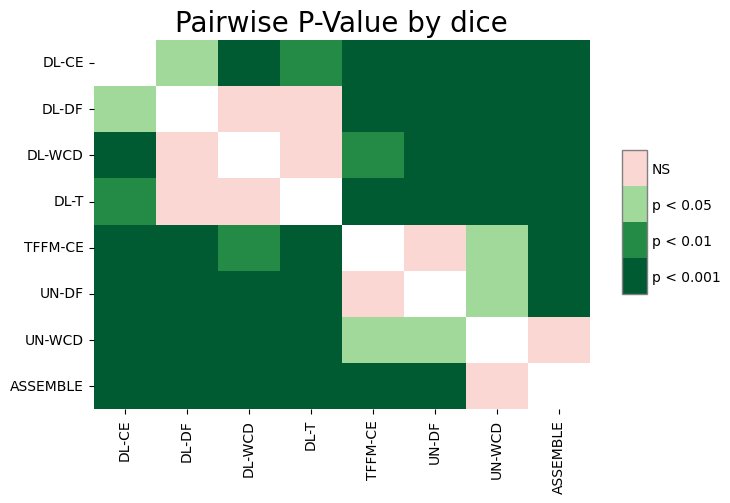

In [173]:
metric = metrics[0]
print(metric)

ax = sp.sign_plot(test_results[metric])[0]

ax.set_title(f'Pairwise P-Value by {metric}', fontdict={'size': 20})
plt.show()

iou


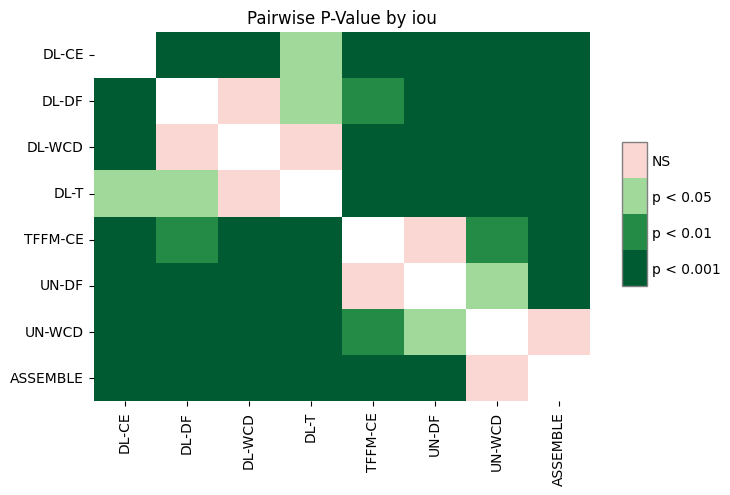

In [174]:
metric = metrics[1]
print(metric)
ax = sp.sign_plot(test_results[metric])[0]
ax.set_title(f'Pairwise P-Value by {metric}')
plt.show()

precision


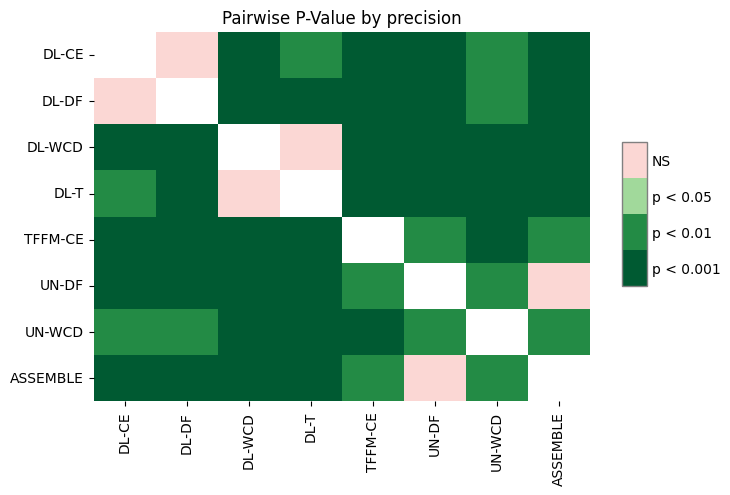

In [175]:
metric = metrics[2]
print(metric)
ax = sp.sign_plot(test_results[metric])[0]
ax.set_title(f'Pairwise P-Value by {metric}')
plt.show()

recall


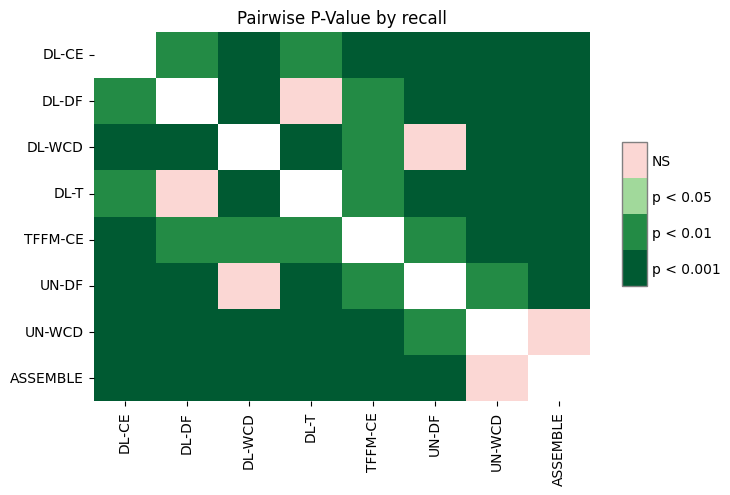

In [176]:
metric = metrics[3]
print(metric)
ax = sp.sign_plot(test_results[metric])[0]
ax.set_title(f'Pairwise P-Value by {metric}')
plt.show()

{'markers': [<matplotlib.collections.PathCollection at 0x1c364686750>,
 'elbows': [<matplotlib.lines.Line2D at 0x1c364685e90>,
 'labels': [Text(0.115, -2, 'DL-CE (0.12)'),
  Text(0.115, -3, 'DL-DF (0.33)'),
  Text(0.115, -4, 'DL-T (0.38)'),
  Text(0.115, -5, 'DL-WCD (0.42)'),
  Text(1.01, -2, '(1) ASSEMBLE'),
  Text(1.01, -3, '(0.88) UN-WCD'),
  Text(1.01, -4, '(0.71) UN-DF'),
  Text(1.01, -5, '(0.67) TFFM-CE')],
 'crossbars': [[<matplotlib.lines.Line2D at 0x1c364691610>],
  [<matplotlib.lines.Line2D at 0x1c36468e890>]]}

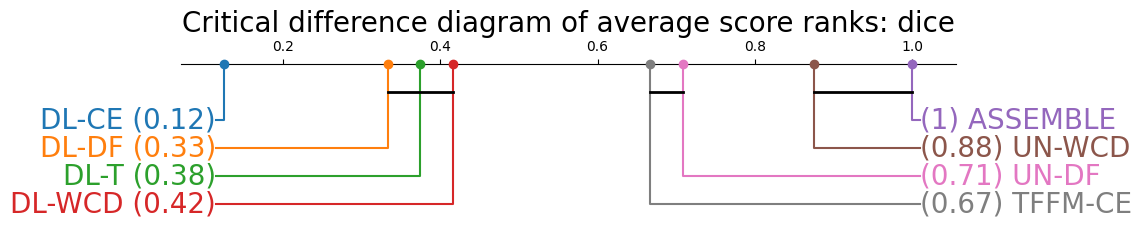

In [177]:
# plt.figure(figsize=(10, 2), dpi=100)
# plt.title('Critical difference diagram of average score ranks')
# sp.critical_difference_diagram(avg_rank_iou, test_results_iou)

metric = metrics[0]
plt.figure(figsize=(10, 2), dpi=100)
plt.title(f'Critical difference diagram of average score ranks: {metric}', fontdict={'size': 20})
sp.critical_difference_diagram(avg_ranks[metric], test_results[metric], label_props={'size': 20})


{'markers': [<matplotlib.collections.PathCollection at 0x1c368261490>,
 'elbows': [<matplotlib.lines.Line2D at 0x1c3682605d0>,
 'labels': [Text(0.115, -3, 'DL-CE (0.12)'),
  Text(0.115, -4, 'DL-T (0.29)'),
  Text(0.115, -5, 'DL-WCD (0.38)'),
  Text(0.115, -6, 'DL-DF (0.46)'),
  Text(1.01, -3, '(1) ASSEMBLE'),
  Text(1.01, -4, '(0.88) UN-WCD'),
  Text(1.01, -5, '(0.71) UN-DF'),
  Text(1.01, -6, '(0.67) TFFM-CE')],
 'crossbars': [[<matplotlib.lines.Line2D at 0x1c36828bb90>],
  [<matplotlib.lines.Line2D at 0x1c368268d90>]]}

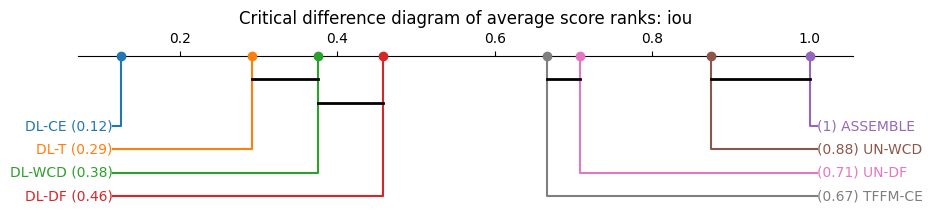

In [178]:
metric = metrics[1]
plt.figure(figsize=(10, 2), dpi=100)
plt.title(f'Critical difference diagram of average score ranks: {metric}')
sp.critical_difference_diagram(avg_ranks[metric], test_results[metric])


{'markers': [<matplotlib.collections.PathCollection at 0x1c3649799d0>,
 'elbows': [<matplotlib.lines.Line2D at 0x1c364cac810>,
 'labels': [Text(0.15666666666666665, -2, 'DL-WCD (0.17)'),
  Text(0.15666666666666665, -3, 'DL-T (0.21)'),
  Text(0.15666666666666665, -4, 'DL-CE (0.42)'),
  Text(0.15666666666666665, -5, 'DL-DF (0.46)'),
  Text(1.01, -2, '(1) TFFM-CE'),
  Text(1.01, -3, '(0.83) UN-DF'),
  Text(1.01, -4, '(0.79) ASSEMBLE'),
  Text(1.01, -5, '(0.62) UN-WCD')],
 'crossbars': [[<matplotlib.lines.Line2D at 0x1c368127610>],
  [<matplotlib.lines.Line2D at 0x1c364caf890>]]}

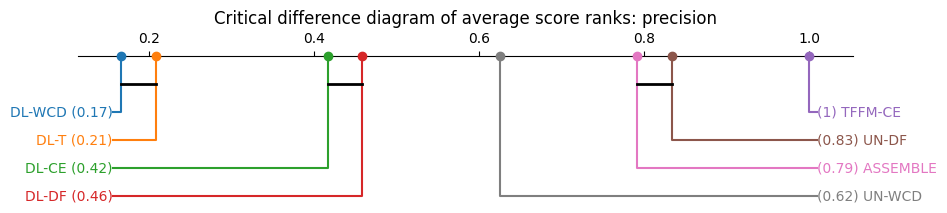

In [179]:
metric = metrics[2]
plt.figure(figsize=(10, 2), dpi=100)
plt.title(f'Critical difference diagram of average score ranks: {metric}')
sp.critical_difference_diagram(avg_ranks[metric], test_results[metric])


{'markers': [<matplotlib.collections.PathCollection at 0x1c36829c590>,
 'elbows': [<matplotlib.lines.Line2D at 0x1c36618a550>,
 'labels': [Text(0.115, -2, 'DL-CE (0.12)'),
  Text(0.115, -3, 'DL-DF (0.29)'),
  Text(0.115, -4, 'DL-T (0.33)'),
  Text(0.115, -5, 'TFFM-CE (0.5)'),
  Text(0.9683333333333334, -2, '(0.96) ASSEMBLE'),
  Text(0.9683333333333334, -3, '(0.92) UN-WCD'),
  Text(0.9683333333333334, -4, '(0.71) UN-DF'),
  Text(0.9683333333333334, -5, '(0.67) DL-WCD')],
 'crossbars': [[<matplotlib.lines.Line2D at 0x1c3681f3b90>],
  [<matplotlib.lines.Line2D at 0x1c3681d0710>]]}

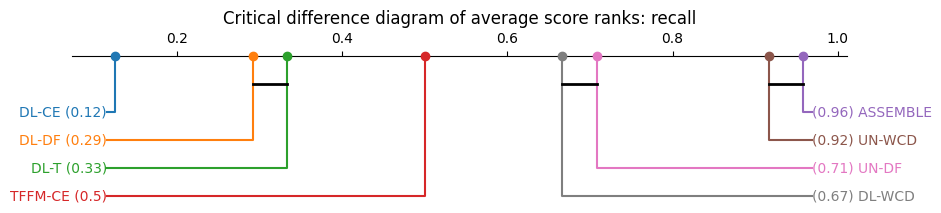

In [180]:
metric = metrics[3]
plt.figure(figsize=(10, 2), dpi=100)
plt.title(f'Critical difference diagram of average score ranks: {metric}')
sp.critical_difference_diagram(avg_ranks[metric], test_results[metric])
